# 🧠 Avaliação Final do Modelo de Predição de Asma

Este notebook tem como objetivo avaliar o desempenho final dos modelos treinados para predição de asma, utilizando os dados de teste previamente separados.  
Serão carregados os conjuntos de dados, os modelos salvos e calculadas métricas de desempenho, importância das variáveis e análises complementares.


## 📚 Importação das bibliotecas

Nesta seção, são carregadas as principais bibliotecas utilizadas para análise e visualização dos resultados, incluindo `numpy`, `pandas`, `matplotlib` e `joblib` (para carregar modelos treinados).


## 📂 Carregamento dos dados de teste

Os arquivos `X_test.csv`, `y_test.csv` e `X_test_keras.csv` contêm, respectivamente:
- As variáveis independentes do conjunto de teste (`X_test`);
- O vetor de resposta indicando presença de asma (`y_test`);
- A versão dos dados preparada para modelos em Keras (`X_test_keras`).

A seguir, os dados são carregados e armazenados em variáveis apropriadas.


In [1]:
### libs ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

### dados ###
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")["num_asma"].values
X_test_keras = pd.read_csv("X_test_keras.csv").values[:, 1:]

In [2]:
# modelos sklearn
reglog = joblib.load("logreg_pipeline_trained.joblib")
rf = joblib.load("randomforest_pipeline_trained.joblib")
xgb = joblib.load("xgboost_pipeline_trained.joblib")

# modelo Keras
from tensorflow import keras
nn = keras.models.load_model("modelo_rn_keras.h5")
nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### **Acurácia**

In [3]:
from sklearn.metrics import accuracy_score
preds_nn = nn.predict(X_test_keras)
preds_nn_cat = (preds_nn > 0.5).astype(int)

print(f"Acurácia da Regressão Logística: {accuracy_score(y_test, reglog.predict(X_test)):.1%}")
print(f"Acurácia do Random Forest: {accuracy_score(y_test, rf.predict(X_test)):.1%}")
print(f"Acurácia do XGBoost: {accuracy_score(y_test, xgb.predict(X_test)):.1%}")
print(f"Acurácia da Rede Neural: {accuracy_score(y_test, preds_nn_cat):.1%}")


568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Acurácia da Regressão Logística: 69.7%
Acurácia do Random Forest: 53.4%
Acurácia do XGBoost: 81.7%
Acurácia da Rede Neural: 90.8%


### **ROC AUC**

568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


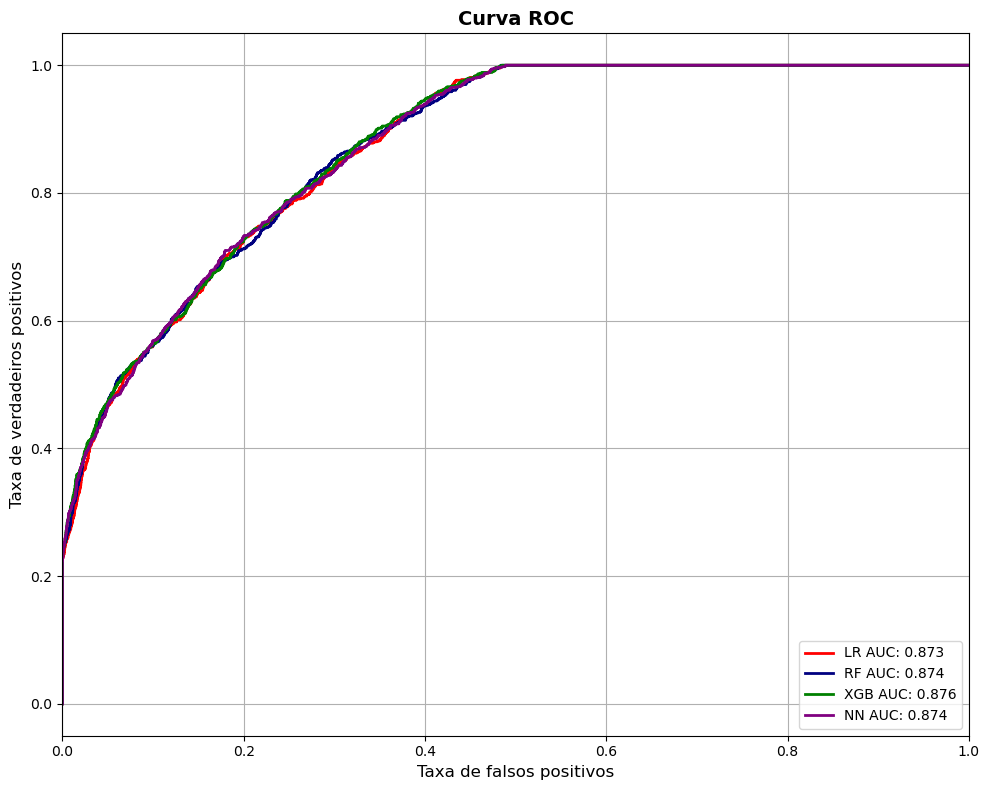

In [4]:
# Curva ROC
from sklearn.metrics import roc_curve, auc
lr_fpr, lr_tpr, _ = roc_curve(y_test, reglog.predict_proba(X_test)[:, 1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb.predict_proba(X_test)[:, 1])
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn.predict(X_test_keras))

# Gráfico
plt.figure(figsize=(10, 8))

plt.plot(lr_fpr, lr_tpr,
         color='red', 
         linewidth=2,
         label=f"LR AUC: {auc(lr_fpr, lr_tpr):.3f}"
         )

plt.plot(rf_fpr, rf_tpr,
         color='navy',
         linewidth=2,
         label=f"RF AUC: {auc(rf_fpr, rf_tpr):.3f}"
         )

plt.plot(xgb_fpr, xgb_tpr,
         color='green', 
         linewidth=2,
         label=f"XGB AUC: {auc(xgb_fpr, xgb_tpr):.3f}"
        )

plt.plot(nn_fpr, nn_tpr,
         color='purple', 
         linewidth=2,
         label=f"NN AUC: {auc(nn_fpr, nn_tpr):.3f}"
         )

# Configurações do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('Taxa de falsos positivos', fontsize=12)
plt.ylabel('Taxa de verdadeiros positivos', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

### **Recall e Precisão**

In [5]:
from sklearn.metrics import recall_score
print(f"Recall da Regressão Logística: {recall_score(y_test, reglog.predict(X_test)):.1%}")
print(f"Recall do Random Forest: {recall_score(y_test, rf.predict(X_test)):.1%}")
print(f"Recall do XGBoost: {recall_score(y_test, xgb.predict(X_test)):.1%}")
print(f"Recall da Rede Neural: {recall_score(y_test, preds_nn_cat):.1%}")

Recall da Regressão Logística: 85.1%
Recall do Random Forest: 100.0%
Recall do XGBoost: 68.4%
Recall da Rede Neural: 50.4%


### **Comparativo**

In [6]:
from sklearn.metrics import precision_score

metricas = {
    "acurácia":[
        accuracy_score(y_test, reglog.predict(X_test)),
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, xgb.predict(X_test)),
        accuracy_score(y_test, preds_nn_cat)
              ],
    "auc":[
        auc(lr_fpr, lr_tpr),
        auc(rf_fpr, rf_tpr),
        auc(xgb_fpr, xgb_tpr),
        auc(nn_fpr, nn_tpr)
    ],
    "recall":[
        recall_score(y_test, reglog.predict(X_test)),
        recall_score(y_test, rf.predict(X_test)),
        recall_score(y_test, xgb.predict(X_test)),
        recall_score(y_test, preds_nn_cat)
    ],
    "precision":[
        precision_score(y_test, reglog.predict(X_test)),
        precision_score(y_test, rf.predict(X_test)),
        precision_score(y_test, xgb.predict(X_test)),
        precision_score(y_test, preds_nn_cat)
    ]
}

pd.DataFrame(metricas, index=["Log Reg", "RF", "XGB", "NN"])

,acurácia,auc,recall,precision
Log Reg,0.696863,0.873087,0.851064,0.123879
RF,0.534397,0.874184,1.000000,0.095477
XGB,0.817061,0.875847,0.684211,0.167260
NN,0.908420,0.874396,0.503919,0.269300


## **Explicabilidade**

XGB é um modelo altamente explicável, o que facilita a tarefa de compreender suas predições. Vamos verificar seus coeficientes para entender a importância das *features* na predição.

In [3]:
# conjunto completo de dados
X = pd.read_csv("dados_preprocessados.csv").drop(["num_asma"], axis=1)
y = pd.read_csv("dados_preprocessados.csv")["num_asma"].values

In [4]:
# treinar nos dados completos
xgb.fit(X, y)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unk...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.006525917448358937, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=9, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=-1,
                               num_parallel_tree=None, random_state=None, ...))])

In [5]:
# selecionar modelo
best_model = xgb.named_steps["clf"]

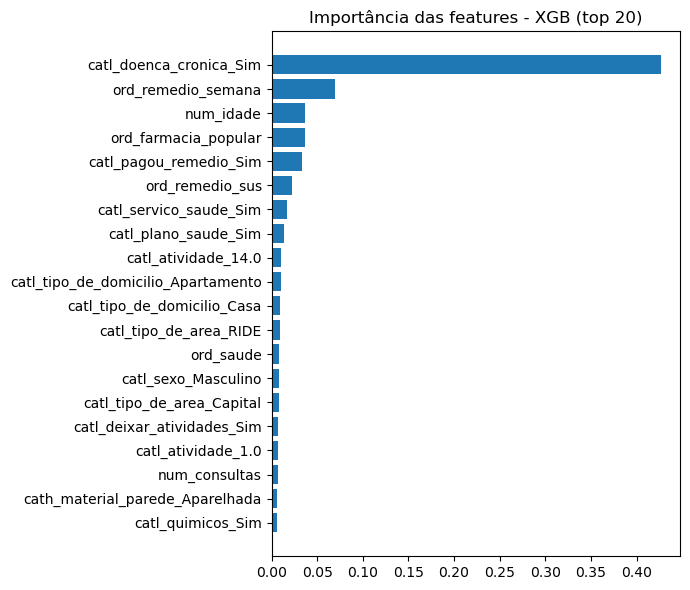

In [11]:
# Selecionar modelo
best_model = xgb.named_steps["clf"]

# Obter o pré-processador do pipeline
pre_clean = xgb.named_steps["pre"] # ajuste o nome se necessário

# Obter os nomes das features após o pré-processamento
try:
    fn = pre_clean.get_feature_names_out(X.columns)
except Exception:
    # Se não conseguir, transformar X para obter o número de features e criar nomes genéricos
    X_proc = pre_clean.transform(X)
    fn = np.array([f"f{i}" for i in range(X_proc.shape[1])])

imp = getattr(best_model, "feature_importances_", None)
if imp is None or len(imp) == 0:
    b = best_model.get_booster().get_score(importance_type="gain")
    imp = np.array([b.get(f"f{i}", 0) for i in range(len(fn))])

idx = np.argsort(imp)[-20:]
plt.figure(figsize=(7, max(4, len(idx)*0.3)))
plt.barh(np.array(fn)[idx], np.array(imp)[idx])
plt.title("Importância das features - XGB (top 20)")
plt.tight_layout()

# Exportar o gráfico em alta resolução
plt.savefig('feature_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.savefig('feature_importance_xgb.svg', dpi=300, bbox_inches='tight')

plt.show()

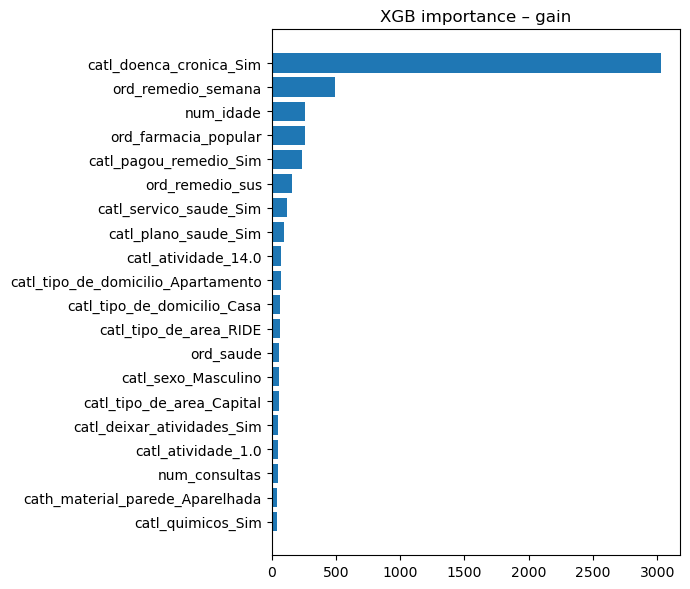

In [12]:
import numpy as np, matplotlib.pyplot as plt

def plot_xgb_importance(best_model, pre, X, kind="gain", top=20):
    fn = getattr(pre, "get_feature_names_out", lambda c: c)(X.columns)
    b = best_model.get_booster().get_score(importance_type=kind)
    imp = np.array([b.get(f"f{i}", 0) for i in range(len(fn))])
    idx = np.argsort(imp)[-top:]
    plt.figure(figsize=(7, max(4, top*0.3)))
    plt.barh(np.array(fn)[idx], imp[idx]); plt.title(f"XGB importance – {kind}")
    plt.tight_layout(); plt.show()

plot_xgb_importance(best_model, pre_clean, X, kind="gain", top=20)
# troque kind para "weight" ou "cover" se quiser comparar


In [31]:
y_pred = xgb.predict(X)


In [32]:
X["predito"] = y_pred
X["real"] = y
erros = X[(y_pred != y)]
acertos = X[(y_pred == y)]
print("Total de amostras:", len(X))
print("Acertos:", len(acertos))
print("Erros:", len(erros))
print("Taxa de erro:", len(erros) / len(X))


Total de amostras: 90846
Acertos: 73985
Erros: 16861
Taxa de erro: 0.18559980626554828
